# Случайное блуждание

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 5: Случайные блуждания на графах"
* Документация:
    * https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html
    * https://numpy.org/doc/stable/reference/generated/numpy.diag.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_power.html
    * https://numpy.org/doc/stable/reference/generated/numpy.allclose.html

In [126]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## Вопросы для совместного обсуждения

1\. Обсудите понятие случайного блуждания на графах. 

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите граф карате-клуба. Получите матрицу смежности `A` этого графа. Получите на ее основе матрицу переходов `P` по следующему правилу:

$$\mathbf{P}=\mathbf{D}^{-1}\mathbf{A}$$

Продемонстрируйте, что выполняются условия (1) и (2).

$0 \le p_{ij} \le 1$ (1)

$\sum_j p_{ij}=1$    (2)

- [✔] Проверено на семинаре

In [127]:
G = nx.karate_club_graph()

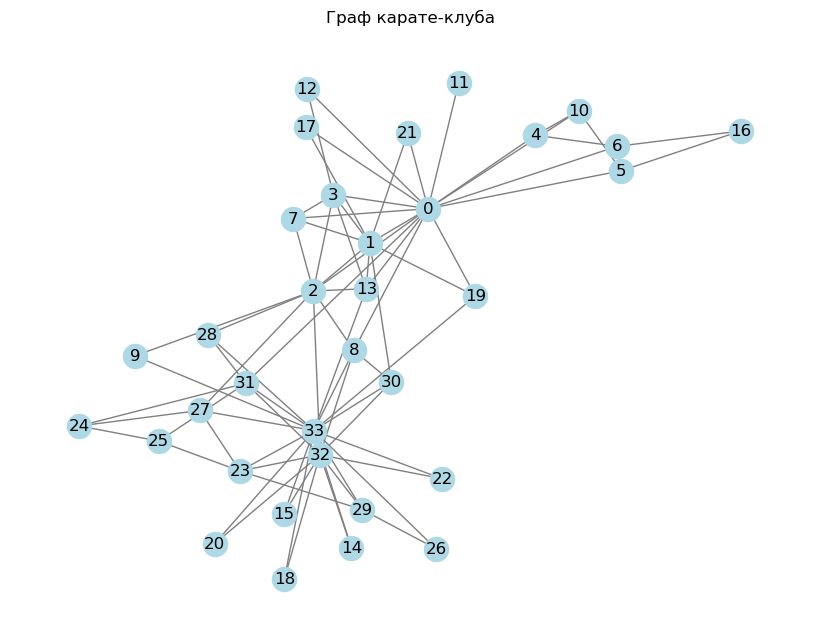

Количество узлов: 34
Количество ребер: 78


In [128]:
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Граф карате-клуба")
plt.show()
print(f"Количество узлов: {G.number_of_nodes()}")
print(f"Количество ребер: {G.number_of_edges()}")

In [129]:
# матрицу смежности A
A = nx.adjacency_matrix(G).toarray()
print("\nМатрица смежности A (первые 5x5 элементов):")
print(A[:5, :5])
print(f"Размер матрицы A: {A.shape}")


Матрица смежности A (первые 5x5 элементов):
[[0 4 5 3 3]
 [4 0 6 3 0]
 [5 6 0 3 0]
 [3 3 3 0 0]
 [3 0 0 0 0]]
Размер матрицы A: (34, 34)


In [130]:
#Рассчитаем матрицу степеней D
degrees = A.sum(axis=1)

In [131]:
#Создаем диагональную матрицу D, где на диагонали стоят степени узлов
D = np.diag(degrees)


In [132]:
inv_degrees = 1.0 / degrees
D_inv = np.diag(inv_degrees)

print("\nМатрица D^-1 (первые 5 диагональных элементов):")
print(np.diag(D_inv)[ :5])


Матрица D^-1 (первые 5 диагональных элементов):
[0.02380952 0.03448276 0.03030303 0.05555556 0.125     ]


In [133]:
#Получим на ее основе матрицу переходов P по следующему правилу: P = D⁻¹A
P = D_inv @ A 

print("\nМатрица переходов P (первые 5x5 элементов):")
print(np.round(P[:5, :5], 3))
print(f"Размер матрицы P: {P.shape}")


Матрица переходов P (первые 5x5 элементов):
[[0.    0.095 0.119 0.071 0.071]
 [0.138 0.    0.207 0.103 0.   ]
 [0.152 0.182 0.    0.091 0.   ]
 [0.167 0.167 0.167 0.    0.   ]
 [0.375 0.    0.    0.    0.   ]]
Размер матрицы P: (34, 34)


In [134]:
min_val = P.min()
max_val = P.max()
condition1_met = (min_val >= 0) and (max_val <= 1)
print(f"Минимальное значение в P: {min_val:.4f}")
print(f"Максимальное значение в P: {max_val:.4f}")

Минимальное значение в P: 0.0000
Максимальное значение в P: 1.0000


In [135]:
row_sums = P.sum(axis=1)
condition2_met = np.allclose(row_sums, 1.0)
print(f"Суммы по строкам (первые 5): {(row_sums[:5])}")
print(f"{condition2_met}")

Суммы по строкам (первые 5): [1. 1. 1. 1. 1.]
True


<p class="task" id="2"></p>

2\. Создайте вектор начального состояния $\mathbf{p}^0 = [0, ..., 1]^T$. Получите стационарное состояние $\mathbf{p}^\infty$, используя итеративную процедуру

$\mathbf{p}^{t+1}=(\mathbf{P}^{\top})\mathbf{p}^t$ 

Процесс заканчивается, когда $||\mathbf{p}^{t+1} - \mathbf{p}^{t}|| < \epsilon $

Выведите полученный вектор стационарного состояния на экран.

- [✔] Проверено на семинаре

In [136]:
p0 = np.zeros(G.number_of_nodes())
p0[-1] = 1.0  

In [137]:
print(f"\nНачальный вектор состояния p0 (первые/последние 5 элементов):")
if G.number_of_nodes() > 10:
    print(p0[:5].flatten())
    print("...")
    print(p0[-5:].flatten())
else:
    print(p0.flatten())


Начальный вектор состояния p0 (первые/последние 5 элементов):
[0. 0. 0. 0. 0.]
...
[0. 0. 0. 0. 1.]


In [138]:
P_T = P.transpose()

In [139]:
# Задаем параметры для остановки
epsilon = 1e-8  
max_iterations = 1000 

pt = p0.copy() 
iterations = 0


In [140]:
for i in range(max_iterations):
    iterations += 1
    pt_next = P_T @ pt  

    diff_norm = np.linalg.norm(pt_next - pt, ord=1)

    pt = pt_next

    if diff_norm < epsilon:
        print(f"Сходимость достигнута на итерации {iterations}.")
        break

else:
    print(f"Максимальное количество итераций ({max_iterations}) достигнуто.")
    print(f"Последняя норма разности: {diff_norm:.2e}")

Сходимость достигнута на итерации 138.


In [141]:
p_stationary = pt

print(np.round(p_stationary.flatten(), 4))

[0.0909 0.0628 0.0714 0.039  0.0173 0.0303 0.0281 0.0281 0.0368 0.0065
 0.0173 0.0065 0.0087 0.0368 0.0108 0.0152 0.013  0.0065 0.0065 0.0108
 0.0087 0.0087 0.0108 0.0455 0.0152 0.0303 0.013  0.0281 0.013  0.0281
 0.0238 0.0455 0.0823 0.1039]


<p class="task" id="3"></p>

3\. Найдите матрицу перехода к стационарному состоянию $(\mathbf{P}^{\top})^\infty$ при помощи процедуры возведения матрицы в степень.

Докажите, что полученная матрица является матрицей стационарного состояния, т.е. $||(\mathbf{P}^{\top})^{\infty}  -(\mathbf{P}^{\top})(\mathbf{P}^{\top})^{\infty}|| <= \epsilon$

Выведите полученную матрицу на экран.

- [✔] Проверено на семинаре

In [142]:
# Задаем параметры для остановки
epsilon = 1e-8
max_iterations = 1000 

M_current = P_T.copy()
iterations = 0

In [143]:
for i in range(max_iterations):
    iterations += 1
    # Вычисляем следующую степень: (P^T)^(k+1) = P_T * (P^T)^k
    M_next = P_T @ M_current

    diff_norm = np.linalg.norm(M_next - M_current, ord='fro')

    M_current = M_next

    if diff_norm < epsilon:
        print(f"Сходимость матрицы достигнута на итерации {iterations}.")
        break

else: 
    print(f"Предупреждение: Максимальное количество итераций ({max_iterations}) достигнуто.")
    print(f"Последняя норма разности матриц: {diff_norm:.2e}")

Сходимость матрицы достигнута на итерации 142.


In [144]:
M_limit = M_current

print(f"\nПолученная предельная матрица (P^T)^∞ (первые 5x5 элементов, округлено):")
print(np.round(M_limit[:5, :5], 4))
print(f"Размер матрицы: {M_limit.shape}")


Полученная предельная матрица (P^T)^∞ (первые 5x5 элементов, округлено):
[[0.0909 0.0909 0.0909 0.0909 0.0909]
 [0.0628 0.0628 0.0628 0.0628 0.0628]
 [0.0714 0.0714 0.0714 0.0714 0.0714]
 [0.039  0.039  0.039  0.039  0.039 ]
 [0.0173 0.0173 0.0173 0.0173 0.0173]]
Размер матрицы: (34, 34)


In [145]:
#Проверка свойства стационарности: M ≈ (P^T)M"
M_check = P_T @ M_limit

# Вычисляем норму разности между M_limit и (P^T) * M_limit
verification_norm = np.linalg.norm(M_limit - M_check, ord='fro')

print(f"Норма разности ||M_limit - P_T @ M_limit||_fro: {verification_norm:.2e}")
if verification_norm < epsilon * 10: 
    print('Подтверждено') 
else:
    print('Не подтверждено')

Норма разности ||M_limit - P_T @ M_limit||_fro: 8.10e-09
Подтверждено


<p class="task" id="4"></p>

4\. Cоздайте вектор начального состояния $\mathbf{p}^0 = [0, ..., 1]^T $. Получите стационарное состояние $\mathbf{p}^\infty$, воспользовавшись полученной матрицей $(\mathbf{P}^{\top})^\infty$. Решите задачу двумя способами: при помощи матричного умножения и при помощи оператора индексации.

Используя функцию `np.allclose`, покажите, что векторы стационарных состояний, полученные двумя разными методами, совпадают (с точностью до тысячных).

- [✔] Проверено на семинаре

In [ ]:
# Способ 1: при помощи матричного умножения
# p^∞ = (P^T)^∞ * p^0
print("\nСпособ 1: Матричное умножение (P^T)^∞ * p^0")
p_inf_matmul = M_limit @ p0
print(f"p^∞ (матричное умножение, первые 5 элементов): {np.round(p_inf_matmul[:5].flatten(), 5)}")
print(f"p^∞ (матричное умножение, последние 5 элементов): {np.round(p_inf_matmul[-5:].flatten(), 5)}")


Способ 1: Матричное умножение (P^T)^∞ * p^0
p^∞ (матричное умножение, первые 5 элементов): [0.09091 0.06277 0.07143 0.03896 0.01732]
p^∞ (матричное умножение, последние 5 элементов): [0.09091 0.06277 0.07143 0.03896 0.01732]


In [ ]:
# Способ 2: при помощи оператора индексации
# Используем свойство, что все столбцы (P^T)^∞ равны p^∞.
# Возьмем первый столбец (индекс 0).
print("\nСпособ 2: Индексация (взят первый столбец (P^T)^∞)")
# M_limit[:, 0] вернет одномерный массив (n_nodes,)
# Преобразуем его в вектор-столбец (n_nodes, 1) для согласованности
p_inf_indexing = M_limit[:, 0].reshape(-1, 1)
print(f"p^∞ (индексация, первые 5 элементов): {np.round(p_inf_indexing[:5].flatten(), 5)}")
print(f"p^∞ (индексация, последние 5 элементов): {np.round(p_inf_indexing[-5:].flatten(), 5)}")


Способ 2: Индексация (взят первый столбец (P^T)^∞)
p^∞ (индексация, первые 5 элементов): [0.09091 0.06277 0.07143 0.03896 0.01732]
p^∞ (индексация, последние 5 элементов): [0.09091 0.06277 0.07143 0.03896 0.01732]


<p class="task" id="5"></p>

5\. Напишите функцию `generate_walk`, которая принимает на вход граф `G`, начальный узел `node` и генерирует случайное блуждание длины `walk_len`, начинающееся с этого узла. Сгенерируйте несколько реализаций (не меньше 1000) случайных блужданий длины 10 с началом в узле 7 и выясните, в каком узле случайные блуждания заканчиваются чаще всего. Выведите номер этого узла на экран.

- [ ] Проверено на семинаре

In [159]:
import random
from collections import Counter

In [ ]:
def generate_walk(G, node, walk_len):
    if node not in G:
        raise ValueError(f"Начальный узел {node} отсутствует в графе.")
    if walk_len <= 0:
        return []
    
    walk = [node] # Начинаем блуждание с заданного узла
    current_node = node
    
    # Выполняем walk_len - 1 шагов, так как первый узел уже добавлен
    for _ in range(walk_len - 1):
        neighbors = list(G.neighbors(current_node))
        
        # Если у текущего узла нет соседей (тупик), останавливаем блуждание
        if not neighbors:
            break 
            
        # Выбираем случайного соседа для следующего шага
        next_node = random.choice(neighbors)
        walk.append(next_node)
        current_node = next_node
        
    return walk

# Параметры симуляции
start_node = 7
walk_length = 10
num_walks = 5000 # Используем больше 1000 для лучшей статистики

endpoints = []

for _ in range(num_walks):
    walk = generate_walk(G, start_node, walk_length)
    # Убедимся, что блуждание не было пустым или слишком коротким
    if walk: 
        endpoints.append(walk[-1]) # Добавляем последний узел блуждания

# Проверяем, были ли сгенерированы блуждания
if not endpoints:
    print("Не удалось сгенерировать блуждания.")
else:
    endpoint_counts = Counter(endpoints)
    
    most_common_node, count = endpoint_counts.most_common(1)[0]
    
    print(f"После {num_walks} случайных блужданий длины {walk_length}, начавшихся с узла {start_node}:")
    print(f"Чаще всего блуждания заканчиваются в узле: {most_common_node} (встретился {count} раз)")


После 5000 случайных блужданий длины 10, начавшихся с узла 7:
Чаще всего блуждания заканчиваются в узле: 0 (встретился 604 раз)
